In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from statsmodels.tsa.ar_model import AutoReg
import statsmodels.api as sm
from pandas import Timedelta
import warnings

warnings.filterwarnings('ignore')

In [68]:
HORIZON = 1

In [77]:
class Config_HAR:
    # Lag selection
    use_bic: bool = True
    lag_candidates = [1, 5, 22]
    max_bic_lag = 44

    # Data parameters
    initial_train_years = 6
    test_months = 12

    # Transformations
    use_log_transform = True

In [78]:
def load_and_prepare_data(filepath):
    rv = pd.read_csv(filepath)
    rv = rv[["Date", "Volatility", "Type"]]
    rv.rename(columns={"Volatility": "RV_daily"}, inplace=True)
    rv = rv[rv['Type'] == 'QMLE-Trade']
    rv.drop(columns=['Type'], inplace=True)
    rv = rv.set_index("Date")
    rv.index = pd.to_datetime(rv.index)
    rv.index.name = "date"

    print(f"Data loaded: {len(rv)} observations")
    print(f"Date range: {rv.index.min()} to {rv.index.max()}")
    return rv

def create_lagged_features(data, lags):
    df = data.copy()
    for lag in lags:
        df[f'lag_{lag}'] = df['RV_daily'].shift(lag)
    df = df.dropna()
    return df

def prepare_train_test_data(df, train_start, train_end, test_start, test_end):
    train_data = df[train_start:train_end]
    test_data = df[test_start:test_end]
    return train_data, test_data

In [99]:
def calculate_BIC(train_data, max_lag: int = 44):
    bic_values = {}
    for lag in range(2, max_lag + 1):
        model = AutoReg(train_data.iloc[-252:], lags=lag, old_names=False)
        result = model.fit()
        bic_values[lag] = result.bic
    best_lag = min(bic_values, key=bic_values.get)

    chosen = [1]
    if best_lag > 10:
        second_var = int(best_lag * 5/22)
        chosen.append(second_var)
        chosen.append(best_lag)
    else:
        second_var = int(best_lag * 22/5)
        chosen.append(best_lag)
        chosen.append(second_var)

    chosen = sorted(chosen)
    print(f"BIC-selected lag set: {chosen}")
    return chosen

In [100]:
def calculate_mse(y_true, y_pred):
    return mean_squared_error(y_true, y_pred)

def calculate_qlike(y_true_vol, y_pred_vol):
    """Variance QLIKE computed from volatility-level observations and forecasts."""
    y_true_var = np.square(np.maximum(np.asarray(y_true_vol, dtype=float), 1e-8))
    y_pred_var = np.square(np.maximum(np.asarray(y_pred_vol, dtype=float), 1e-8))
    ratio = y_true_var / y_pred_var
    qlike = np.mean(ratio - np.log(ratio) - 1)
    return qlike

In [101]:
def fit_har_model(X, y):
    X_const = sm.add_constant(X, has_constant='add')
    return sm.OLS(y, X_const).fit()

def predict_har_model(model, X):
    X_const = sm.add_constant(X, has_constant='add')
    return model.predict(X_const)

In [102]:
def expanding_window_forecast(rv_data, config):
    # Create lagged features
    if config.use_bic:
        df_with_lags = create_lagged_features(rv_data, list(range(1, config.max_bic_lag + 1)))
    else:
        df_with_lags = create_lagged_features(rv_data, config.lag_candidates)

    # Use horizon from config if present, else default to 1
    h = int(getattr(config, 'forecast_horizon', 1))
    target_col = 'RV_target'
    if h <= 1:
        df_with_lags[target_col] = df_with_lags['RV_daily']
    else:
        #Forward average of the next h days: y_t = (RV_t + ... + RV_{t+h-1}) / h
        fwd_sum = None
        for i in range(1, h+1):
            shifted = df_with_lags['RV_daily'].shift(-i)
            fwd_sum = shifted if fwd_sum is None else (fwd_sum + shifted)
        df_with_lags[target_col] = fwd_sum / h
    # Drop rows where the forward target is unavailable (end-of-sample)
    df_with_lags = df_with_lags.dropna(subset=[target_col])

    print(f"Target constructed as forward average over horizon h={h} (column: {target_col})")


    all_results = []

    start_date = df_with_lags.index[0]
    initial_train_end = start_date + pd.DateOffset(years=config.initial_train_years)
    current_test_start = initial_train_end + Timedelta(days=1)  # no overlap

    print(f"\nStarting expanding window forecasting...")
    print(f"Initial training period: {start_date.date()} to {initial_train_end.date()}")
    print(f"Test slice per window: {config.test_months} month(s)")
    print(f"Using log transformation: {config.use_log_transform}")
    print(f"Use BIC: {config.use_bic}\n")

    window_count = 0
    last_date = df_with_lags.index[-1]

    while current_test_start <= last_date:
        window_count += 1

        train_start = start_date
        train_end = current_test_start - Timedelta(days=1)
        test_end = min(
            current_test_start + pd.DateOffset(months=config.test_months),
            last_date
        )

        # Split data (train/test only)
        train_data, test_data = prepare_train_test_data(
            df_with_lags, train_start, train_end, current_test_start, test_end
        )

        if len(test_data) == 0 or len(train_data) == 0:
            break

        # Select lags
        if config.use_bic:
            selected = calculate_BIC(train_data['RV_daily'], max_lag=config.max_bic_lag)
            feature_cols = [f'lag_{lag}' for lag in selected]
        else:
            feature_cols = [f'lag_{lag}' for lag in config.lag_candidates]
            selected = config.lag_candidates

        # Build matrices
        X_train = train_data[feature_cols].values
        y_train = train_data[target_col].values
        X_test  = test_data[feature_cols].values
        y_test  = test_data[target_col].values

        # Optional log transformation
        if config.use_log_transform:
            X_train_work = np.log(np.maximum(X_train, 1e-8))
            X_test_work  = np.log(np.maximum(X_test, 1e-8))
            y_train_work = np.log(np.maximum(y_train, 1e-8))
        else:
            X_train_work, X_test_work = X_train, X_test
            y_train_work = y_train

        # Fit OLS HAR
        model = fit_har_model(X_train_work, y_train_work)

        # Predict (work space)
        train_pred_work = predict_har_model(model, X_train_work)
        test_pred_work  = predict_har_model(model, X_test_work)

        # Inverse transform if logged
        if config.use_log_transform:
            y_train_level = y_train
            train_pred = np.exp(train_pred_work)
            test_pred  = np.exp(test_pred_work)
        else:
            y_train_level = y_train
            train_pred = train_pred_work
            test_pred  = test_pred_work

        # Metrics
        train_mse = calculate_mse(y_train_level, train_pred)
        test_mse  = calculate_mse(y_test, test_pred)
        train_ql  = calculate_qlike(y_train_level, train_pred)
        test_ql   = calculate_qlike(y_test, test_pred)

        # Log window info
        print(f"--- Window {window_count} ---")
        print(f"Train: {train_start.date()} to {train_end.date()}  (n={len(train_data)})")
        print(f"Test : {current_test_start.date()} to {test_end.date()} (n={len(test_data)})")
        print(f"Lags used: {selected}")
        print(f"In-sample  -> MSE: {train_mse:.6f}, QLIKE: {train_ql:.6f}")
        print(f"Out-of-sample -> MSE: {test_mse:.6f}, QLIKE: {test_ql:.6f}\n")

        # Collect results per test day
        window_df = pd.DataFrame({
            'ticker': 'SPY',
            'date': test_data.index,
            'real_RV': y_test,
            'predicted_RV': test_pred,
            'window': window_count,
            'train_mse': train_mse,
            'test_mse': test_mse,
            'train_qlike': train_ql,
            'test_qlike': test_ql,
            'lags_used': [str(selected)] * len(test_data)
        })
        all_results.append(window_df)

        # Advance to next window
        current_test_start = current_test_start + pd.DateOffset(months=config.test_months)

    if not all_results:
        print("No results generated. Check data range and configuration.")
        return pd.DataFrame(columns=['date','real_RV','predicted_RV','window','train_mse','test_mse','train_qlike','test_qlike','lags_used'])

    results_df = pd.concat(all_results, axis=0, ignore_index=True)
    return results_df


In [103]:
def plot_results(results_df):
    fig, axes = plt.subplots(2, 1, figsize=(14, 10))

    # Time series of actual vs predicted
    ax1 = axes[0]
    ax1.plot(results_df['date'], results_df['real_RV'], label='Actual RV', alpha=0.7, linewidth=1)
    ax1.plot(results_df['date'], results_df['predicted_RV'], label='Predicted RV', alpha=0.7, linewidth=1)
    ax1.set_xlabel('Date')
    ax1.set_ylabel('Realised Volatility')
    ax1.set_title('Actual vs Predicted Realised Volatility')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Scatter plot: Actual vs Predicted with 45-degree line
    ax2 = axes[1]
    ax2.scatter(results_df['real_RV'], results_df['predicted_RV'], alpha=0.6, s=10)
    min_val = min(results_df['real_RV'].min(), results_df['predicted_RV'].min())
    max_val = max(results_df['real_RV'].max(), results_df['predicted_RV'].max())
    ax2.plot([min_val, max_val], [min_val, max_val], linestyle='--', linewidth=1)
    ax2.set_xlabel('Actual RV')
    ax2.set_ylabel('Predicted RV')
    ax2.set_title('Predicted vs Actual Realised Volatility')
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

def print_summary_statistics(results_df):  # summary statistics of evaluation metrics
    print("\n" + "="*60)
    print("SUMMARY STATISTICS")
    print("="*60)

    # Overall metrics
    overall_mse = calculate_mse(results_df['real_RV'], results_df['predicted_RV'])
    overall_qlike = calculate_qlike(results_df['real_RV'].values, results_df['predicted_RV'].values)

    print(f"\nOverall Out-of-Sample Performance:")
    print(f"MSE: {overall_mse:.6f}")
    print(f"QLIKE: {overall_qlike:.6f}")

    # Average metrics across windows
    avg_train_mse = results_df.groupby('window')['train_mse'].first().mean()
    avg_test_mse = results_df.groupby('window')['test_mse'].first().mean()
    avg_train_qlike = results_df.groupby('window')['train_qlike'].first().mean()
    avg_test_qlike = results_df.groupby('window')['test_qlike'].first().mean()

    print(f"\nAverage Performance Across Windows:")
    print(f"In-Sample - MSE: {avg_train_mse:.6f}, QLIKE: {avg_train_qlike:.6f}")
    print(f"Out-of-Sample - MSE: {avg_test_mse:.6f}, QLIKE: {avg_test_qlike:.6f}")

    # Correlation
    correlation = results_df['real_RV'].corr(results_df['predicted_RV'])
    print(f"\nCorrelation between Actual and Predicted: {correlation:.4f}")

    # Number of windows
    n_windows = results_df['window'].nunique()
    print(f"\nTotal number of expanding windows: {n_windows}")
    print(f"Total predictions made: {len(results_df)}")

HAR OLS MODEL
Using forecast horizon: 1 day(s)

Loading data...
Data loaded: 7301 observations
Date range: 1996-01-02 00:00:00 to 2025-04-29 00:00:00
Target constructed as forward average over horizon h=1 (column: RV_target)

Starting expanding window forecasting...
Initial training period: 1996-03-06 to 2002-03-06
Test slice per window: 12 month(s)
Using log transformation: True
Use BIC: True

BIC-selected lag set: [1, 2, 8]
--- Window 1 ---
Train: 1996-03-06 to 2002-03-06  (n=1510)
Test : 2002-03-07 to 2003-03-07 (n=253)
Lags used: [1, 2, 8]
In-sample  -> MSE: 0.004018, QLIKE: 0.084246
Out-of-sample -> MSE: 0.002482, QLIKE: 0.023414

BIC-selected lag set: [1, 2, 8]
--- Window 2 ---
Train: 1996-03-06 to 2003-03-06  (n=1762)
Test : 2003-03-07 to 2004-03-07 (n=252)
Lags used: [1, 2, 8]
In-sample  -> MSE: 0.003675, QLIKE: 0.076042
Out-of-sample -> MSE: 0.000657, QLIKE: 0.020841

BIC-selected lag set: [1, 3, 13]
--- Window 3 ---
Train: 1996-03-06 to 2004-03-06  (n=2014)
Test : 2004-03-07 

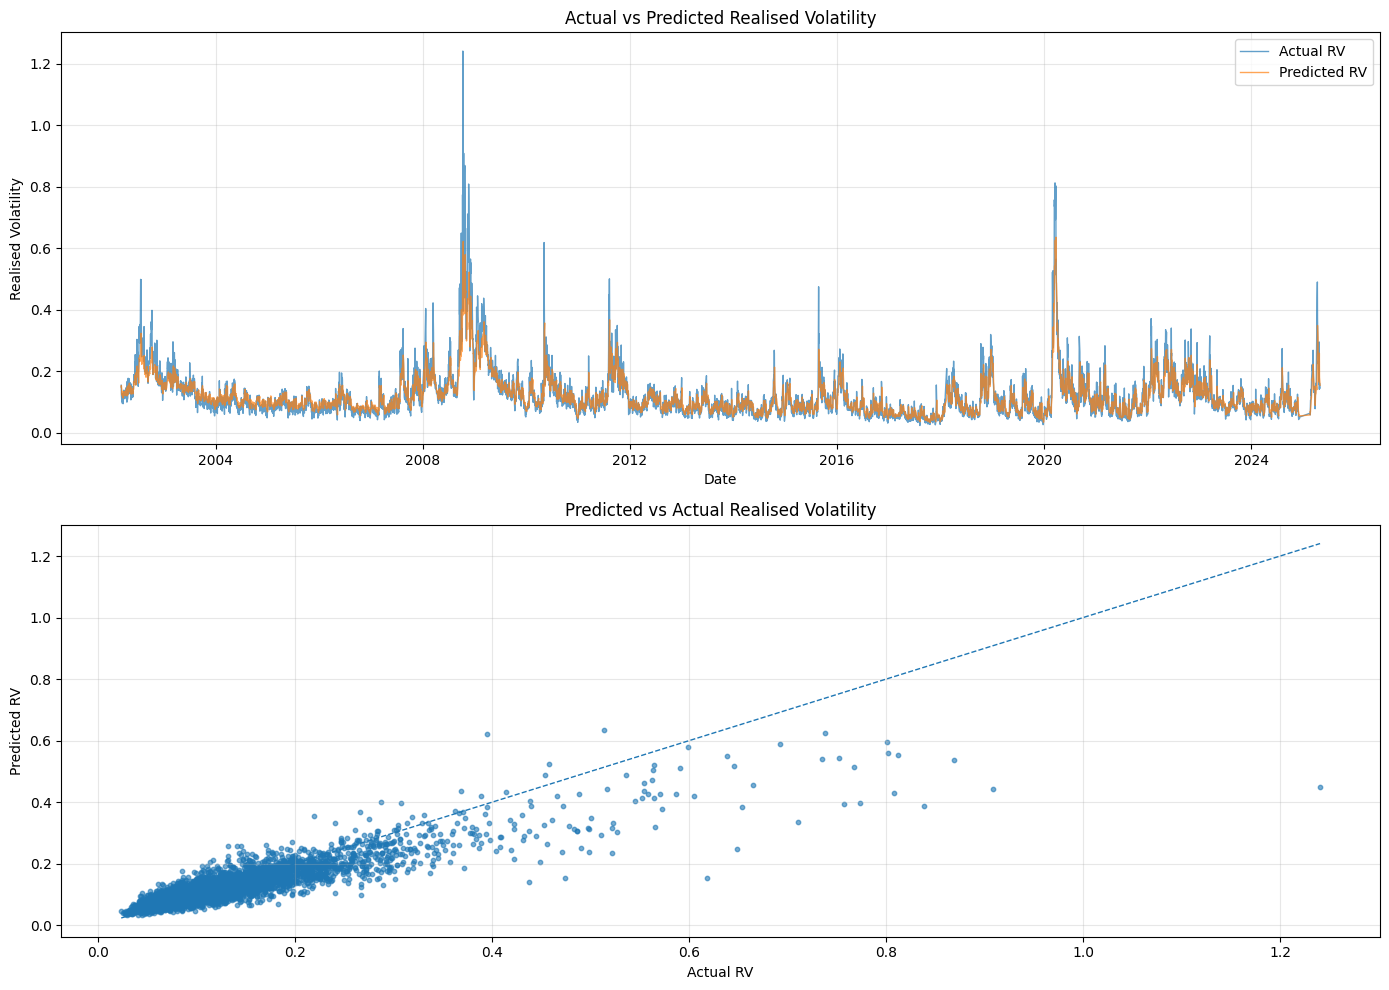

In [104]:
def main_har():
    print("="*60)
    print("HAR OLS MODEL")
    print("="*60)

    # Initialize configuration
    config = Config_HAR()

    # Propagate user horizon switch into config
    try:
        h = int(HORIZON)
    except NameError:
        h = 1
    config.forecast_horizon = h
    print(f"Using forecast horizon: {config.forecast_horizon} day(s)")

    # Load data
    print("\nLoading data...")
    rv_data = load_and_prepare_data('SPY.csv')

    # Expanding window forecast
    results_df = expanding_window_forecast(rv_data, config)

    # Save results
    if config.use_bic:
        output_filename = 'HAR BIC.csv'
    else:
        output_filename = 'HAR.csv'
    results_df.to_csv(output_filename, index=False)
    print(f"\nResults saved to {output_filename}")

    # Print summary statistics
    print_summary_statistics(results_df)

    # Plot results
    print("\nGenerating plots...")
    plot_results(results_df)

if __name__ == "__main__":
    main_har()
